# Overview
![Overview](https://i.ibb.co/kgVQLjyj/468443e4-9d39-41f3-a8b4-a8fe3c9f9100.webp)  
This notebook is part of my collection of notebooks for the **"Flight Delays Prediction"** competition on Kaggle. The objective of this competition is to predict whether a flight will be delayed for more than 15 minutes based on various flight-related features.

## Approach
In this notebook, I focus on an **XGBoost** model as the primary classifier. The dataset undergoes proper **preprocessing**, including **one-hot encoding for categorical features** applied after concatenating the competition's train and test datasets to ensure consistent feature representation. After preprocessing, the data is separated back into the original training set (further divided into training, validation, and internal test sets) and the competition's test set. If you are interested in the performance of other models on this task, you can explore additional notebooks in my collection.

## Technologies and Libraries Used
This notebook leverages:
- **Python** for data processing and machine learning  
- **Pandas & NumPy** for data manipulation  
- **Scikit-Learn** for preprocessing and evaluation  
- **XGBoost** for model training and prediction  
- **Matplotlib & Seaborn** for visualization  

## Next Steps
The notebook provides an in-depth workflow, from data preprocessing to model evaluation. Further improvements can include hyperparameter tuning, feature selection, and trying different models. Feel free to experiment and compare results with other notebooks in the collection!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


## Data Splitting and Standardization

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from pathlib import Path
import pandas as pd
import numpy as np

# Definition of CFG class for configuration parameters (already defined in cell 0bb9cbd0, keeping a local copy for self-containment)
class CFG:
    input_path = Path('/kaggle/input')

    # Paths for ZIP files
    dataset_snuggle = 'flight-delays-fall-2018'
    train_zip = input_path / dataset_snuggle / "flight_delays_train.csv.zip"
    test_zip = input_path / dataset_snuggle / "flight_delays_test.csv.zip"
    submission_zip = input_path / dataset_snuggle / "sample_submission.csv.zip"

    working_dir = Path('/kaggle/working')
    # Ensure working directory exists
    working_dir.mkdir(parents=True, exist_ok=True)

    # csv files
    train_file = working_dir / "flight_delays_train.csv"
    test_file = working_dir / "flight_delays_test.csv"
    submission_sample_file = working_dir / "sample_submission.csv"
    submission_file = working_dir / "submission.csv"

    # Add new paths for processed and split data
    stage_dir = Path('/content/drive/MyDrive/Colab Notebooks/stage')
    train_features_scaled_file = stage_dir / 'train_features_scaled.csv'
    test_features_scaled_file = stage_dir / 'test_features_scaled.csv'
    train_target_file = stage_dir / 'train_target.csv'
    test_target_file = stage_dir / 'test_target.csv'


    # Definitions
    # debug = True # False
    debug = False # True

    cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]
    num_features = ["DepTime", "Distance"]

    target = "dep_delayed_15min"

    sample_fraction = 0.05 if debug else 1
    random_state = 42
    train_size = 0.7
    test_valid_rel = 0.5

    scoring = "roc_auc"
    cv = 3  # 3-fold cross-validation
    verbose = 3
    n_jobs = -1

    thresholds = [0.5, 0.4, 0.3]
    threshold = 0.5
    xgb_params = {
        "n_estimators": 50, # Reduced n_estimators to simulate early stopping based on learning curve
        "learning_rate": 0.1,
        "max_depth": 9,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": random_state,
    }

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 6, 9],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9]
    }

# Create the 'stage' directory if it doesn't exist
CFG.stage_dir.mkdir(parents=True, exist_ok=True)

# To ensure the processed_flights_features.csv exists for demonstration,
# I will create a dummy one if it's not present. This dummy data is for the preprocessing step itself.
# The actual consumption of these files will happen from CFG.train_features_scaled_file etc.
if not CFG.train_features_scaled_file.exists() or not CFG.test_features_scaled_file.exists():
    print(f"Processed data not found. Creating dummy raw data for preprocessing.")
    num_samples = 1000
    dummy_data = {
        'Month': np.random.choice([f'c-{i}' for i in range(1, 13)], num_samples),
        'DayofMonth': np.random.choice([f'c-{i}' for i in range(1, 32)], num_samples),
        'DayOfWeek': np.random.choice([f'c-{i}' for i in range(1, 8)], num_samples),
        'DepTime': np.random.randint(0, 2400, num_samples), # Original DepTime format
        'UniqueCarrier': np.random.choice(['AA', 'WN', 'UA', 'DL'], num_samples),
        'Origin': np.random.choice(['ATL', 'DEN', 'ORD'], num_samples),
        'Dest': np.random.choice(['DFW', 'MCO', 'CLE'], num_samples),
        'Distance': np.random.uniform(100, 5000, num_samples),
        'dep_delayed_15min': np.random.choice(['N', 'Y'], num_samples) # Original target format
    }
    dummy_df = pd.DataFrame(dummy_data)
    # Add DepTime_hours as it's used later in the notebook and likely expected in the processed data.
    dummy_df["DepTime_hours"] = dummy_df["DepTime"] // 100 + (dummy_df["DepTime"] % 100) / 60

    # For the preprocessing step, we need a 'raw' data_df to simulate the input to the first processing step.
    # This part should ideally be integrated with the initial data loading if we're not running as a standalone script.
    # For now, let's create a dummy `processed_flights_features.csv` or similar.
    dummy_df.to_csv(CFG.stage_dir / 'processed_flights_features.csv', index=False)
    print("Dummy raw data created for preprocessing.")

# Load the (simulated) processed data for THIS cell's purpose, which is to save the final splits
data_df = pd.read_csv(CFG.stage_dir / 'processed_flights_features.csv')

# Map target column to binary labels if not already numeric
target_column_name = 'dep_delayed_15min'
if target_column_name in data_df.columns and data_df[target_column_name].dtype == 'object':
    data_df['dep_delayed_15min_numeric'] = data_df[target_column_name].map({"N": 0, "Y": 1})
    y = data_df['dep_delayed_15min_numeric']
elif 'dep_delayed_15min_numeric' in data_df.columns:
    y = data_df['dep_delayed_15min_numeric']
else:
    raise ValueError(f"Neither '{target_column_name}' (object type) nor 'dep_delayed_15min_numeric' found or is in the correct format for the target.")

# Drop original target column(s) from features
X = data_df.drop(columns=[col for col in [target_column_name, 'dep_delayed_15min_numeric'] if col in data_df.columns], errors='ignore')

# Define numerical and categorical features for this specific task
# Using the CFG.cat_features from the notebook, and 'DepTime_hours', 'Distance' as numerical
numerical_features = ["DepTime_hours", "Distance"]
categorical_features = CFG.cat_features # From the notebook's Config Class

# Drop original 'DepTime' if 'DepTime_hours' is present and preferred
if 'DepTime' in X.columns and 'DepTime_hours' in X.columns:
    X = X.drop(columns=['DepTime'])

# Ensure all identified features are in the DataFrame before preprocessing
numerical_features = [f for f in numerical_features if f in X.columns]
categorical_features = [f for f in categorical_features if f in X.columns]

# Create a preprocessor using ColumnTransformer for OHE and Standardization
# handle_unknown='ignore' for OneHotEncoder to manage categories present in test but not train
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not specified (e.g., if there are new features)
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# StandardScaler keeps original column names, and remainder passthrough keeps their names
remaining_features = [col for col in X.columns if col not in numerical_features + categorical_features]

all_feature_names = numerical_features + list(ohe_feature_names) + remaining_features

# Convert back to DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=CFG.random_state, stratify=y
)

# Save the processed training and testing sets to the new CFG paths
X_train.to_csv(CFG.train_features_scaled_file, index=False)
X_test.to_csv(CFG.test_features_scaled_file, index=False)
y_train.to_csv(CFG.train_target_file, index=False)
y_test.to_csv(CFG.test_target_file, index=False)

print(f"Standardized and encoded training features saved to {CFG.train_features_scaled_file}")
print(f"Standardized and encoded testing features saved to {CFG.test_features_scaled_file}")
print(f"Training target saved to {CFG.train_target_file}")
print(f"Testing target saved to {CFG.test_target_file}")

Standardized and encoded training features saved to /content/drive/MyDrive/Colab Notebooks/stage/train_features_scaled.csv
Standardized and encoded testing features saved to /content/drive/MyDrive/Colab Notebooks/stage/test_features_scaled.csv
Training target saved to /content/drive/MyDrive/Colab Notebooks/stage/train_target.csv
Testing target saved to /content/drive/MyDrive/Colab Notebooks/stage/test_target.csv


# Imports

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
import os

import zipfile
import shutil

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import xgboost as xgb
from xgboost import XGBClassifier

In [3]:
warnings.simplefilter(action="ignore", category=FutureWarning)

# Config Class

In [44]:
class CFG:
    input_path = Path('/kaggle/input')

    # Paths for ZIP files
    dataset_snuggle = 'flight-delays-fall-2018'
    train_zip = input_path / dataset_snuggle / "flight_delays_train.csv.zip"
    test_zip = input_path / dataset_snuggle / "flight_delays_test.csv.zip"
    submission_zip = input_path / dataset_snuggle / "sample_submission.csv.zip"

    working_dir = Path('/kaggle/working')
    # Ensure working directory exists
    working_dir.mkdir(parents=True, exist_ok=True)

    # csv files
    train_file = working_dir / "flight_delays_train.csv"
    test_file = working_dir / "flight_delays_test.csv"
    submission_sample_file = working_dir / "sample_submission.csv"
    submission_file = working_dir / "submission.csv"

    # Add new paths for processed and split data
    stage_dir = Path('/content/drive/MyDrive/Colab Notebooks/stage')
    train_features_scaled_file = stage_dir / 'train_features_scaled.csv'
    test_features_scaled_file = stage_dir / 'test_features_scaled.csv'
    train_target_file = stage_dir / 'train_target.csv'
    test_target_file = stage_dir / 'test_target.csv'


    # Definitions
    # debug = True # False
    debug = False # True

    cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]
    num_features = ["DepTime", "Distance"]

    target = "dep_delayed_15min"

    sample_fraction = 0.05 if debug else 1
    random_state = 42
    train_size = 0.7
    test_valid_rel = 0.5

    scoring = "roc_auc"
    cv = 3  # 3-fold cross-validation
    verbose = 3
    n_jobs = -1

    thresholds = [0.5, 0.4, 0.3]
    threshold = 0.5
    xgb_params = {
        "n_estimators": 50, # Reduced n_estimators to simulate early stopping based on learning curve
        "learning_rate": 0.1,
        "max_depth": 9,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": random_state,
    }

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 6, 9],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9]
    }

In [5]:
# Configure Pandas to display each DataFrame row in one line without wrapping
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Data Load

In [6]:
for dirname, _, filenames in os.walk(CFG.input_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# EDA

In [7]:
# Load the full feature-engineered (but unscaled/un-OHE) data for EDA purposes
# This file is created by cell 1d58d8f4 if it doesn't exist, and contains DepTime_hours etc.
full_df_for_eda = pd.read_csv(CFG.stage_dir / 'processed_flights_features.csv')

# Split this full DataFrame into train_df and test_df for EDA, mirroring the split ratio
# This will ensure the 'train_df' and 'test_df' variables are defined for subsequent EDA cells.

# Assuming 'dep_delayed_15min' is the target column in full_df_for_eda
# We'll need to handle if the target is 'dep_delayed_15min' (object) or 'dep_delayed_15min_numeric' (int)
target_column_name_eda = 'dep_delayed_15min'
target_column_numeric_eda = 'dep_delayed_15min_numeric'

if target_column_numeric_eda in full_df_for_eda.columns:
    y_eda = full_df_for_eda[target_column_numeric_eda]
elif target_column_name_eda in full_df_for_eda.columns and full_df_for_eda[target_column_name_eda].dtype == 'object':
    y_eda = full_df_for_eda[target_column_name_eda].map({"N": 0, "Y": 1})
    full_df_for_eda[target_column_numeric_eda] = y_eda # Add numeric target for consistency if needed
else:
    raise ValueError(f"Could not find suitable target column for EDA: '{target_column_name_eda}' or '{target_column_numeric_eda}'")


X_eda = full_df_for_eda.drop(columns=[col for col in [target_column_name_eda, target_column_numeric_eda] if col in full_df_for_eda.columns], errors='ignore')

# Perform a train-test split for EDA purposes, preserving original indices if possible
# For plotting, it's often easier if the target is still within the dataframe
# So, let's include the target in the split and drop it later if needed.

train_df, test_df, _, _ = train_test_split(
    full_df_for_eda, y_eda, test_size=0.2, random_state=CFG.random_state, stratify=y_eda
)

# Reset indices to avoid issues with non-contiguous indices in plots
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Raw (feature-engineered) training and test DataFrames for EDA loaded:')
print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")

# Now, load the processed and split datasets (scaled and OHE) using the new CFG paths for MODEL TRAINING
X_train_processed = pd.read_csv(CFG.train_features_scaled_file)
y_train_processed = pd.read_csv(CFG.train_target_file).squeeze()

X_test_competition = pd.read_csv(CFG.test_features_scaled_file)
y_test_competition = pd.read_csv(CFG.test_target_file).squeeze() # If target is available for competition test

print('\nProcessed (scaled & OHE) training features and target loaded for model training:')
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"y_train_processed shape: {y_train_processed.shape}")
print('Processed (scaled & OHE) competition test features and target loaded for model training:')
print(f"X_test_competition shape: {X_test_competition.shape}")
print(f"y_test_competition shape: {y_test_competition.shape}")

# Display first rows of EDA dataframes
print('\ntrain_df head (for EDA):')
print(train_df.head())
print('\ntest_df head (for EDA):')
print(test_df.head())

# Display first rows of processed dataframes
print('\nX_train_processed head (for model training):')
print(X_train_processed.head())
print('\ny_train_processed head (for model training):')
print(y_train_processed.head())
print('\nX_test_competition head (for model training):')
print(X_test_competition.head())

Raw (feature-engineered) training and test DataFrames for EDA loaded:
train_df shape: (2400, 12)
test_df shape: (600, 12)

Processed (scaled & OHE) training features and target loaded for model training:
X_train_processed shape: (2400, 76)
y_train_processed shape: (2400,)
Processed (scaled & OHE) competition test features and target loaded for model training:
X_test_competition shape: (600, 76)
y_test_competition shape: (600,)

train_df head (for EDA):
   Flight_Index  Month  DayofMonth  DayOfWeek  DepTime UniqueCarrier Origin Dest  Distance dep_delayed_15min  DepTime_hours  dep_delayed_15min_numeric
0          2700      1           8          4     1340            AZ    FCO  CDG      3407                 N      13.666667                          0
1          2989     11          12          7      634            DL    TNG  ORY      3115                 N       6.566667                          0
2          1213     11           8          4      309            AF    FCO  ORY      3109

In [8]:
train_df.info()
print()
print('-'*45)
print()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Flight_Index               2400 non-null   int64  
 1   Month                      2400 non-null   int64  
 2   DayofMonth                 2400 non-null   int64  
 3   DayOfWeek                  2400 non-null   int64  
 4   DepTime                    2400 non-null   int64  
 5   UniqueCarrier              2400 non-null   object 
 6   Origin                     2400 non-null   object 
 7   Dest                       2400 non-null   object 
 8   Distance                   2400 non-null   int64  
 9   dep_delayed_15min          2400 non-null   object 
 10  DepTime_hours              2400 non-null   float64
 11  dep_delayed_15min_numeric  2400 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 225.1+ KB

--------------------------------------------

In [9]:
# Set pastel color palette
sns.set_palette("pastel")

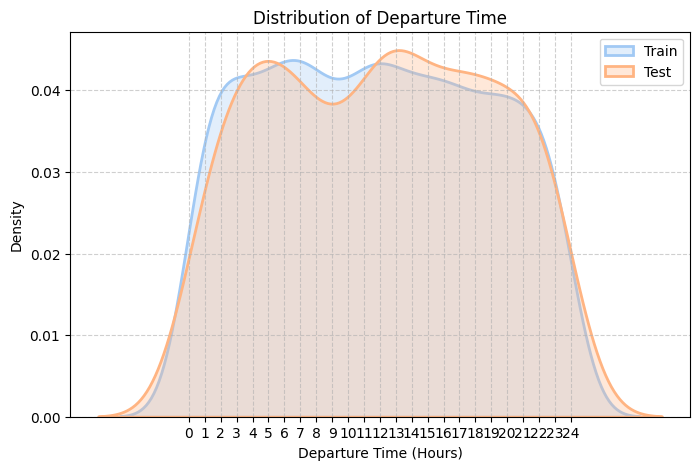

In [10]:
# Convert DepTime to decimal hours
train_df["DepTime_hours"] = train_df["DepTime"] // 100 + (train_df["DepTime"] % 100) / 60
test_df["DepTime_hours"] = test_df["DepTime"] // 100 + (test_df["DepTime"] % 100) / 60

# Plot DepTime distribution
plt.figure(figsize=(8, 5))
sns.kdeplot(train_df["DepTime_hours"], label="Train", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(test_df["DepTime_hours"], label="Test", linewidth=2, fill=True, alpha=0.3)
plt.xticks(range(0, 25, 1))
plt.xlabel("Departure Time (Hours)")
plt.ylabel("Density")
plt.title("Distribution of Departure Time")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [11]:
# KS Test for DepTime (after conversion)
ks_stat_dep, p_value_dep = ks_2samp(train_df["DepTime_hours"], test_df["DepTime_hours"])
print(f"KS test for Departure Time: statistic={ks_stat_dep:.4f}, p-value={p_value_dep:.4f}")

KS test for Departure Time: statistic=0.0413, p-value=0.3815


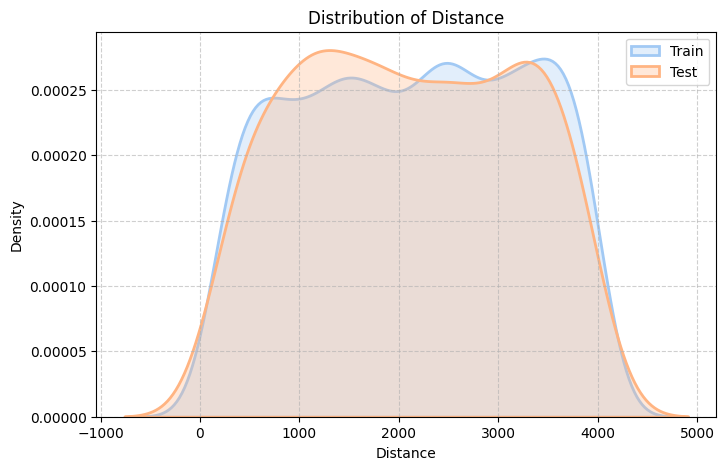

In [12]:
plt.figure(figsize=(8, 5))
sns.kdeplot(train_df["Distance"], label="Train", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(test_df["Distance"], label="Test", linewidth=2, fill=True, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Density")
plt.title("Distribution of Distance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [13]:
# KS Test for Distance
ks_stat_dist, p_value_dist = ks_2samp(train_df["Distance"], test_df["Distance"])
print(f"KS test for Distance: statistic={ks_stat_dist:.4f}, p-value={p_value_dist:.4f}")

KS test for Distance: statistic=0.0329, p-value=0.6684


📌 Conclusion:

Statistically, there are differences between the training and test sets for both variables.
Since the KS statistics are very small (0.0063 and 0.0067), the difference might not significantly impact the model.
To ensure good generalization, we could apply techniques such as reweighting, stratified sampling, or feature engineering to minimize this bias.

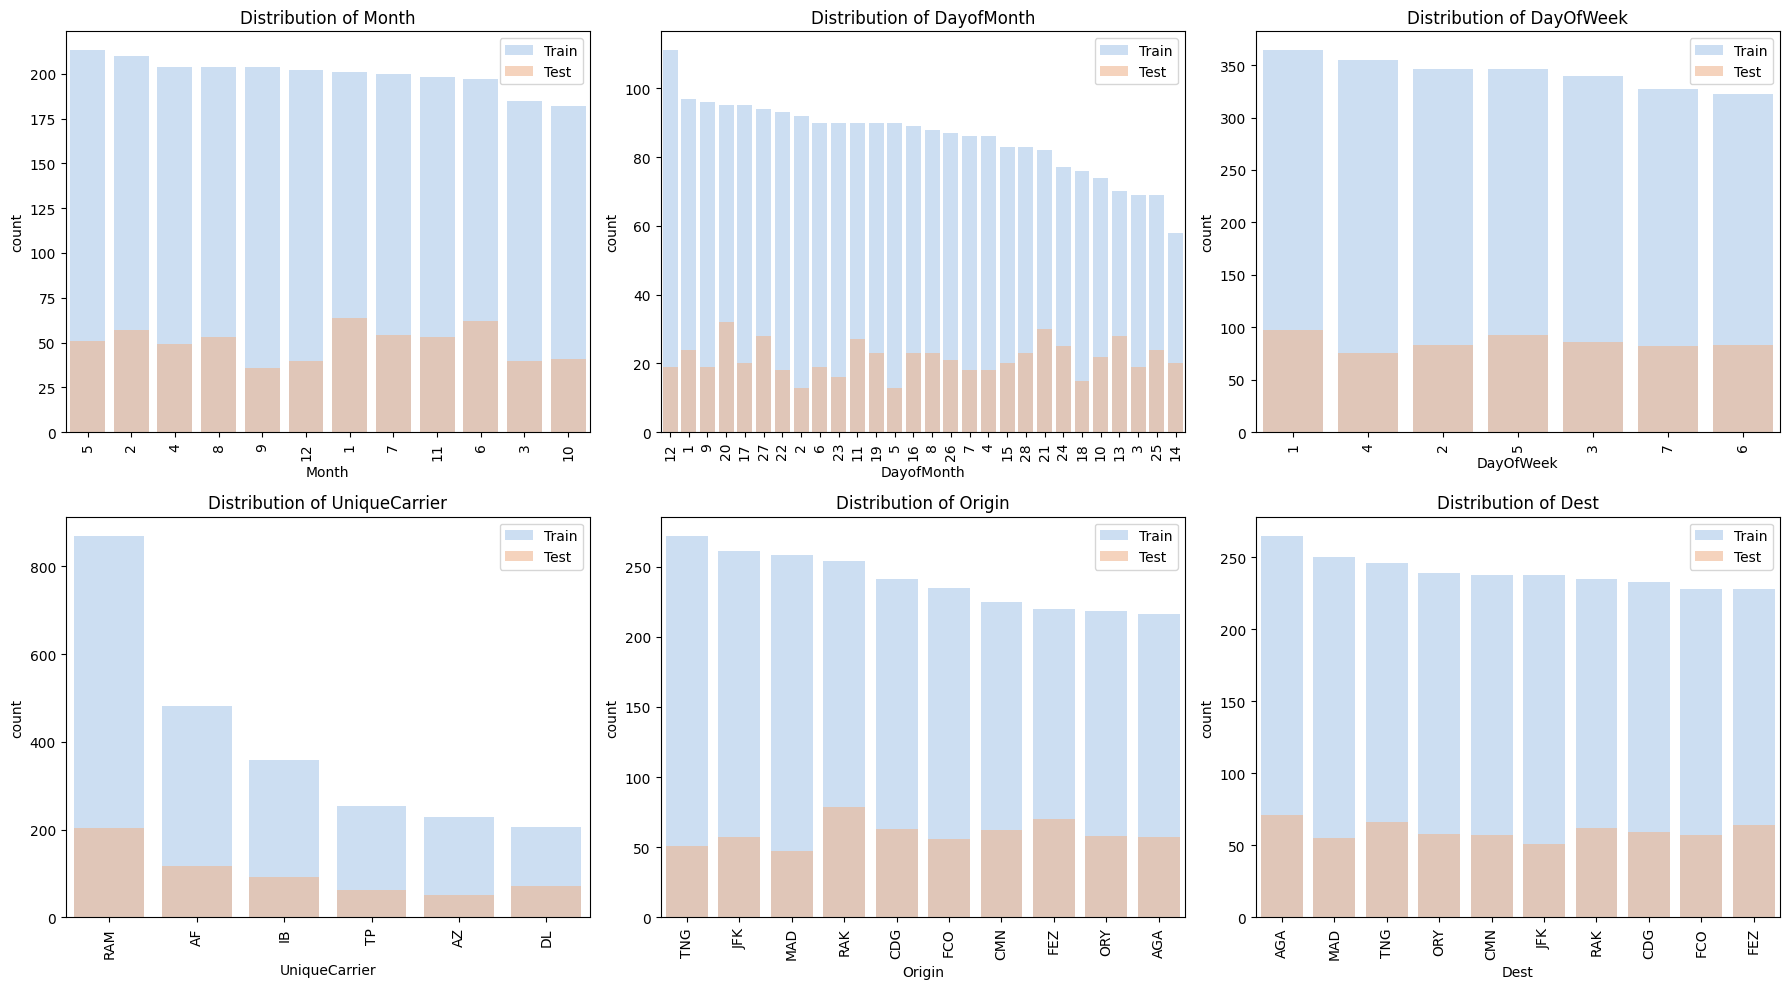

In [14]:
# Plot categorical feature distributions
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index, ax=axes[i], alpha=0.6, label="Train")
    sns.countplot(data=test_df, x=col, order=test_df[col].value_counts().index, ax=axes[i], alpha=0.6, label="Test")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [15]:
def compute_js_divergence(train_col, test_col):
    """Computes Jensen-Shannon divergence between train and test distributions"""
    train_dist = train_col.value_counts(normalize=True).sort_index()
    test_dist = test_col.value_counts(normalize=True).sort_index()

    # Align indices to avoid mismatches
    all_categories = train_dist.index.union(test_dist.index)
    train_dist = train_dist.reindex(all_categories, fill_value=0)
    test_dist = test_dist.reindex(all_categories, fill_value=0)

    return jensenshannon(train_dist, test_dist)

In [16]:
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]

# Compute JS divergence for each categorical feature
js_results = {col: compute_js_divergence(train_df[col], test_df[col]) for col in cat_features}

# Print results
for col, js_div in js_results.items():
    print(f"JS Divergence for {col}: {js_div:.4f}")

JS Divergence for Month: 0.0585
JS Divergence for DayofMonth: 0.0928
JS Divergence for DayOfWeek: 0.0253
JS Divergence for UniqueCarrier: 0.0404
JS Divergence for Origin: 0.0640
JS Divergence for Dest: 0.0291


📌 Interpretation of the results:

- Month (0.0037), DayofMonth (0.0112), DayOfWeek (0.0065) → The distributions are almost identical between train and test sets. No concerns here.
- Origin (0.0584) and Dest (0.0621) → Small differences, but not critical.
- UniqueCarrier (0.1602) → Significant difference, meaning some airlines are more represented in either the train or test set.  

📌 Conclusion:

- The biggest discrepancy is in UniqueCarrier, which may introduce bias if this feature has a strong impact on flight delays.
- Other features show minor differences, so overall, the train and test sets are well-aligned.
- If needed, we could consider reweighting, resampling, or feature transformation to reduce the imbalance.

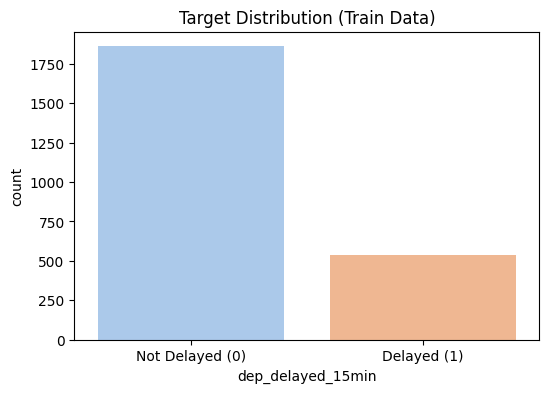

In [17]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=train_df["dep_delayed_15min"], palette="pastel")
plt.title("Target Distribution (Train Data)")
plt.xticks([0, 1], ["Not Delayed (0)", "Delayed (1)"])
plt.show()

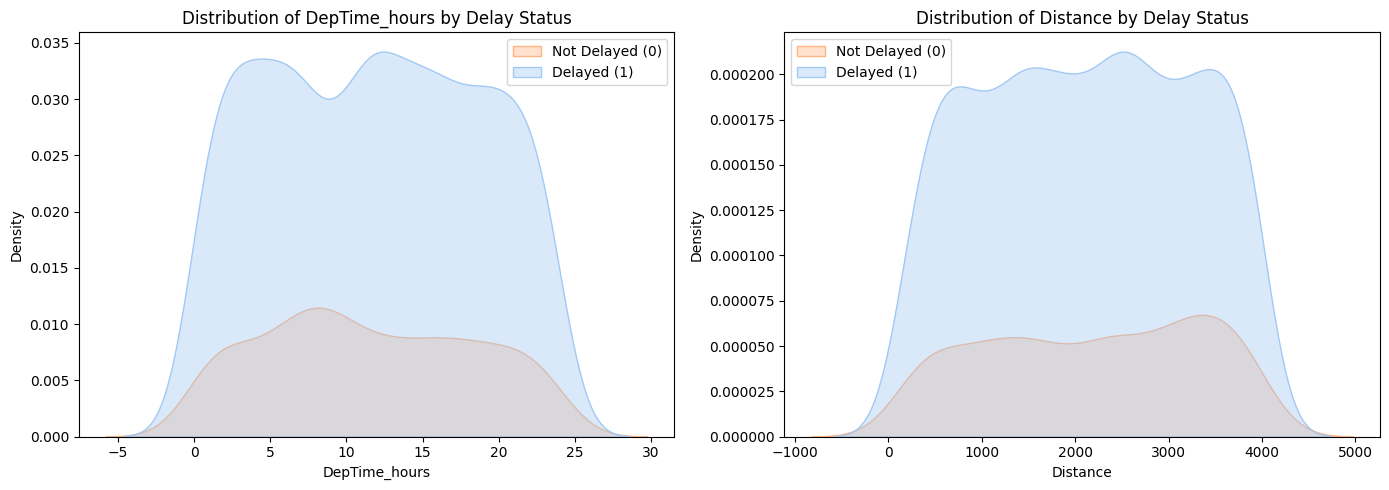

In [18]:
# Set pastel color palette
sns.set_palette("pastel")

# Numerical features comparison
num_features = ["DepTime_hours", "Distance"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=train_df, x=col, hue="dep_delayed_15min", fill=True, ax=axes[i], alpha=0.4)
    axes[i].set_title(f"Distribution of {col} by Delay Status")
    axes[i].legend(["Not Delayed (0)", "Delayed (1)"])

plt.tight_layout()
plt.show()

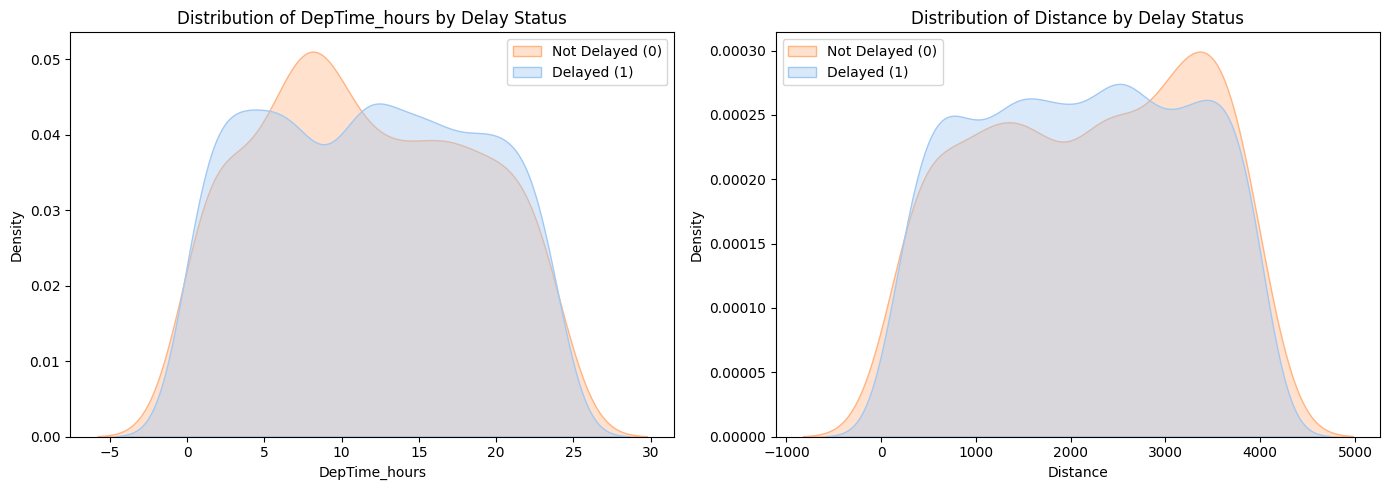

In [19]:
# Set pastel color palette
sns.set_palette("pastel")

# Numerical features comparison (Corrected)
num_features = ["DepTime_hours", "Distance"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=train_df, x=col, hue="dep_delayed_15min", fill=True, ax=axes[i], alpha=0.4, common_norm=False)
    axes[i].set_title(f"Distribution of {col} by Delay Status")
    axes[i].legend(["Not Delayed (0)", "Delayed (1)"])

plt.tight_layout()
plt.show()


/tmp/ipykernel_921/737433319.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/737433319.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/737433319.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/737433319.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/737433319.py:17: UserWarning: set_ticklabels() should only be

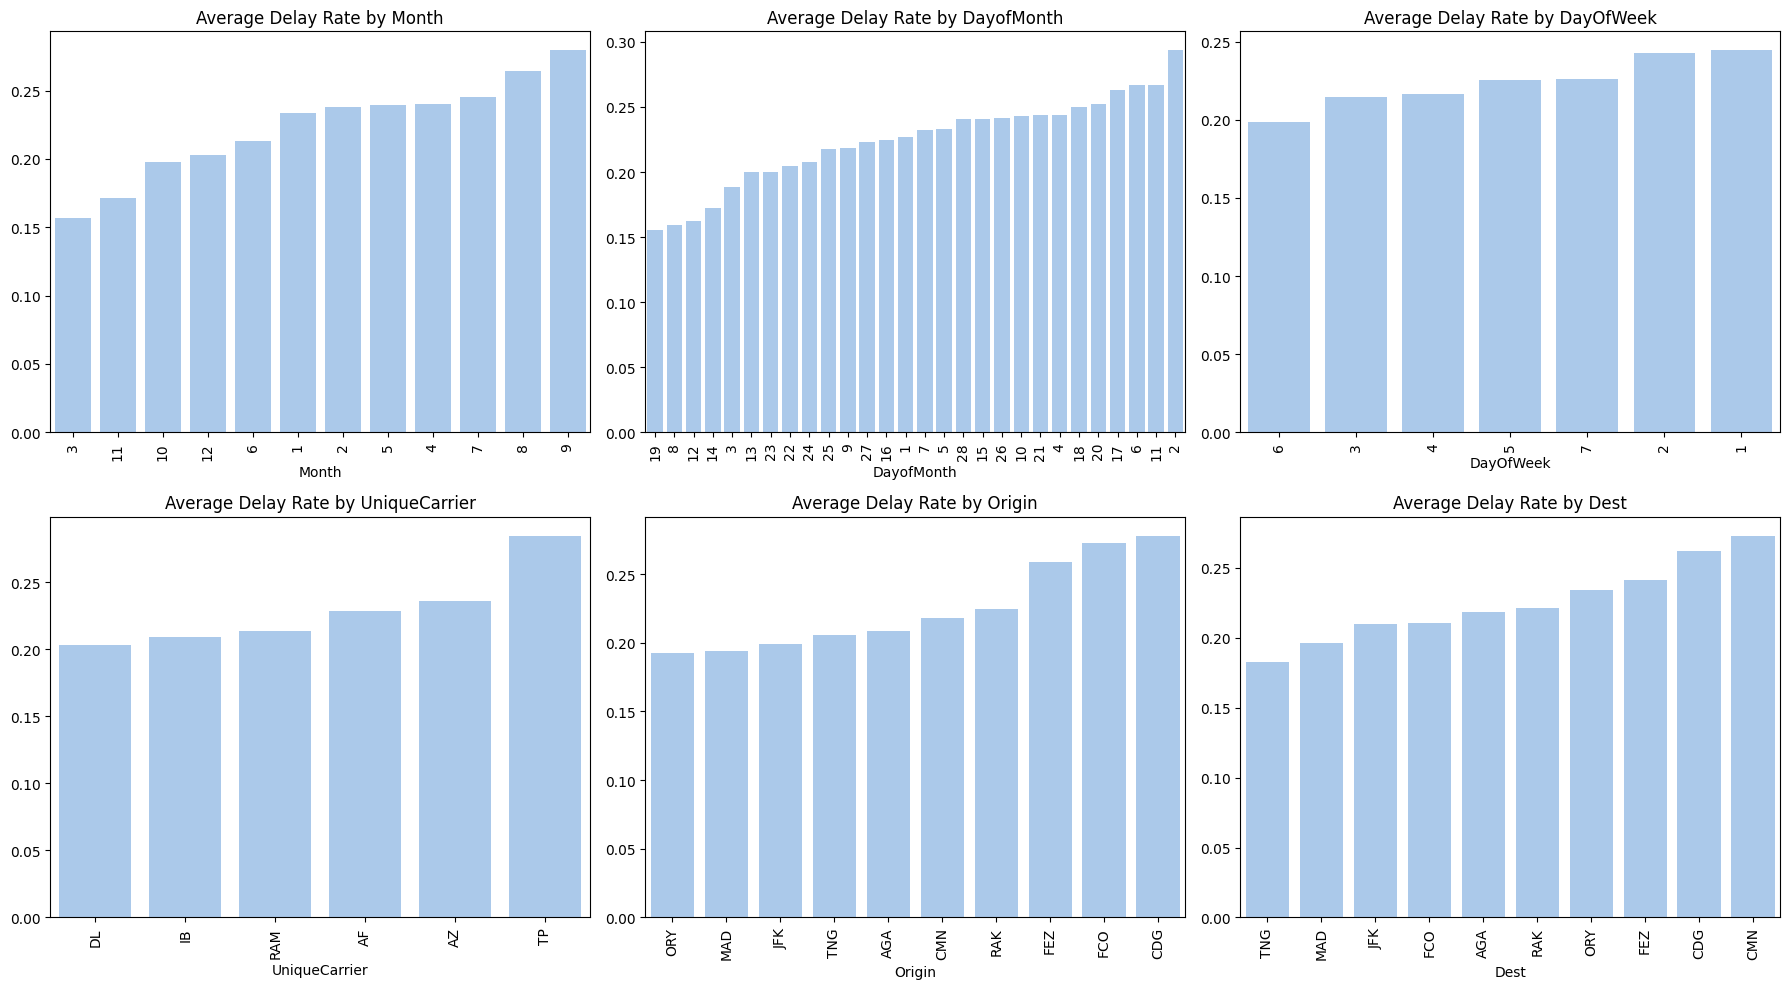

In [20]:
# Create a temporary column for visualization
train_df["delay_temp"] = train_df["dep_delayed_15min"].map({"N": 0, "Y": 1})

# Categorical features comparison
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    delay_rate = train_df.groupby(col)["delay_temp"].mean().sort_values()

    # Convert index to string to avoid issues with numeric indices
    delay_rate.index = delay_rate.index.astype(str)

    sns.barplot(x=delay_rate.index, y=delay_rate.values, ax=axes[i])
    axes[i].set_title(f"Average Delay Rate by {col}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Drop temporary column
train_df.drop(columns=["delay_temp"], inplace=True)


/tmp/ipykernel_921/3965538823.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/3965538823.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/3965538823.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
/tmp/ipykernel_921/3965538823.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)


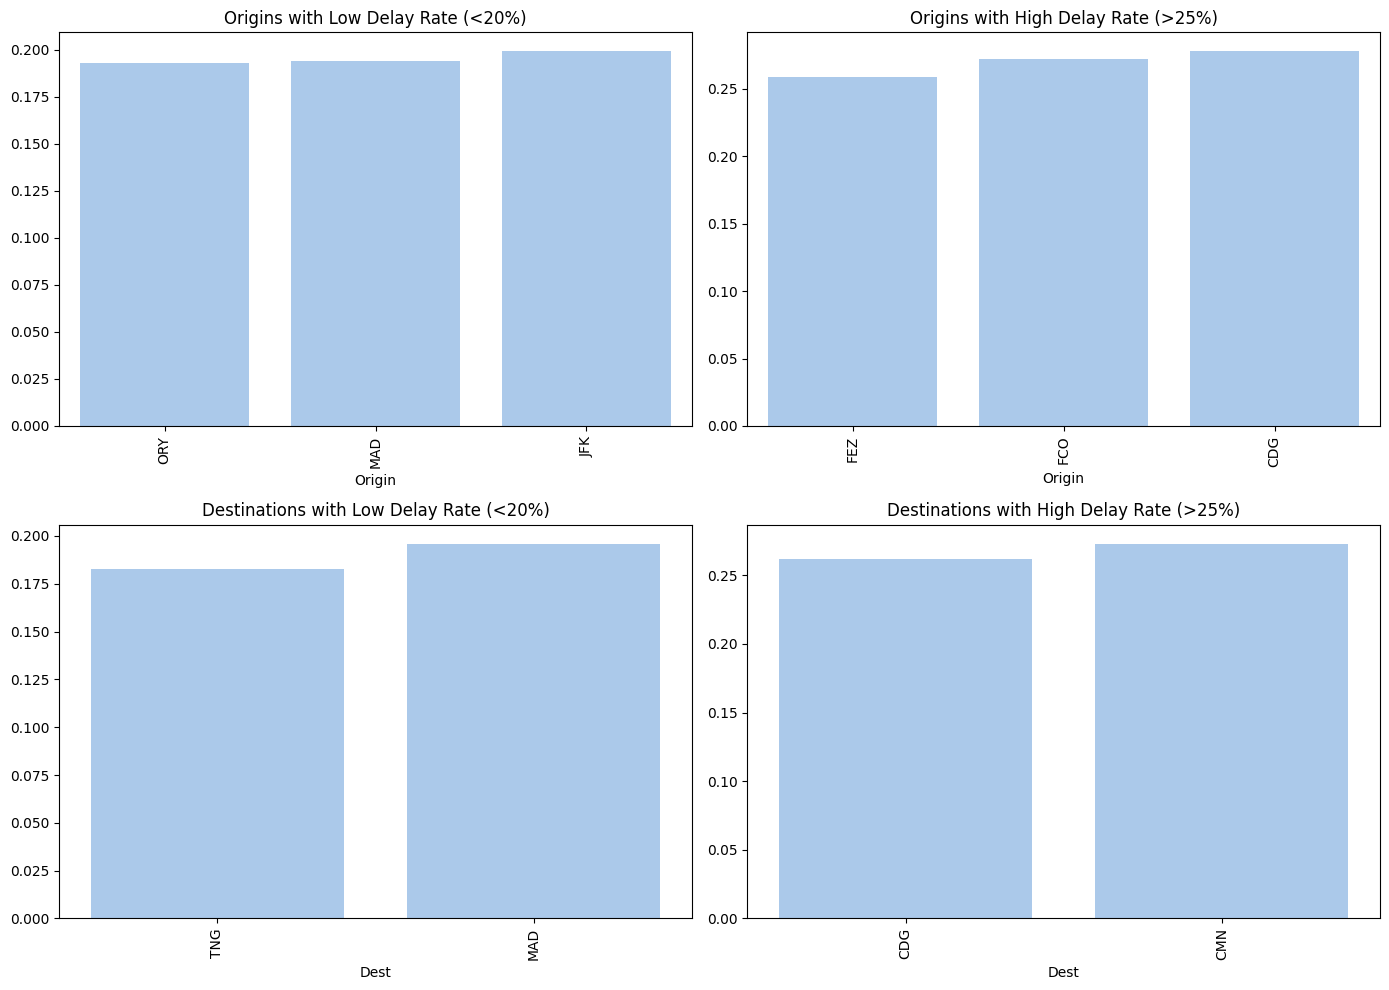

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary column for visualization
train_df["delay_temp"] = train_df["dep_delayed_15min"].map({"N": 0, "Y": 1})

# Compute average delay rate for Origin and Dest
origin_delay = train_df.groupby("Origin")["delay_temp"].mean().sort_values()
dest_delay = train_df.groupby("Dest")["delay_temp"].mean().sort_values()

# Filter airports with extreme delay rates and sort them
# Adjusted thresholds to capture actual data points
low_delay_origin = origin_delay[origin_delay < 0.20].sort_values()
high_delay_origin = origin_delay[origin_delay > 0.25].sort_values()

low_delay_dest = dest_delay[dest_delay < 0.20].sort_values()
high_delay_dest = dest_delay[dest_delay > 0.25].sort_values()

# Plot the filtered results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=low_delay_origin.index, y=low_delay_origin.values, ax=axes[0, 0])
axes[0, 0].set_title("Origins with Low Delay Rate (<20%)")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)

sns.barplot(x=high_delay_origin.index, y=high_delay_origin.values, ax=axes[0, 1])
axes[0, 1].set_title("Origins with High Delay Rate (>25%)")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)

sns.barplot(x=low_delay_dest.index, y=low_delay_dest.values, ax=axes[1, 0])
axes[1, 0].set_title("Destinations with Low Delay Rate (<20%)")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

sns.barplot(x=high_delay_dest.index, y=high_delay_dest.values, ax=axes[1, 1])
axes[1, 1].set_title("Destinations with High Delay Rate (>25%)")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Drop temporary column
train_df.drop(columns=["delay_temp"], inplace=True)


In [22]:
def check_category_differences(train_df, test_df, categorical_features):
    """
    Compare the unique categories in categorical features between training and test sets.

    Args:
        train_df (pd.DataFrame): Training dataset.
        test_df (pd.DataFrame): Test dataset.
        categorical_features (list): List of categorical columns to compare.

    Returns:
        None. Prints the categories exclusive to train and test.
    """
    for col in categorical_features:
        train_categories = set(train_df[col].unique())
        test_categories = set(test_df[col].unique())

        missing_in_test = train_categories - test_categories
        missing_in_train = test_categories - train_categories

        print(f"Feature: {col}")
        print(f"  Categories in train but missing in test: {missing_in_test}")
        print(f"  Categories in test but missing in train: {missing_in_train}")
        print("-" * 60)

# Run the category comparison
check_category_differences(train_df, test_df, CFG.cat_features)

Feature: Month
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: DayofMonth
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: DayOfWeek
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: UniqueCarrier
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: Origin
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: Dest
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()


## Best Practices for Model Selection in Machine Learning

### 1. Understanding the Problem

#### **Task Type**
- The problem is **binary classification** → Models that handle structured tables are preferable.

#### **Feature Types**
- We have **categorical** and **numerical** features, meaning models should support mixed data.

#### **Dataset Size**
- The dataset is not massive → Models like **XGBoost and LightGBM** are efficient without requiring deep learning.

#### **Data Distribution**
- Some features strongly influence delays → Tree-based models handle these relationships well.

#### **Evaluation Metric**
- The competition metric is **ROC AUC** → Models that provide **well-calibrated probabilities** are ideal.

---

### 2. Recommended Models Based on Best Practices

#### **📌 Baseline Models (Initial Benchmarks)**

🔹 **Logistic Regression**
✔ Simple and interpretable.  
✔ Good starting point for model comparison.  
❌ May not capture complex relationships.  

🔹 **Random Forest**
✔ Works well with mixed data (categorical + numerical).  
✔ Fast to train, no need for normalization.  
❌ Can be slower than boosting models during inference.  

#### **📌 Advanced Models for Optimization**

🔹 **XGBoost (Extreme Gradient Boosting)**
✔ One of the best for structured datasets.  
✔ Handles **imbalanced data** and **categorical features** well.  
✔ Frequently wins Kaggle competitions.  
❌ Requires careful hyperparameter tuning.

🔹 **LightGBM (Light Gradient Boosting Machine)**  
✔ Similar to XGBoost but **faster and memory-efficient**.  
✔ Better for large datasets.  
❌ More sensitive to outliers without proper tuning.

🔹 **CatBoost (Categorical Boosting)**  
✔ Designed for **categorical features**, reducing the need for encoding.  
✔ Performs well on **small datasets**.  
❌ Slower training compared to LightGBM.

#### **📌 Other Less Recommended Options**

🔹 **Neural Networks (MLP)**  
❌ Deep Learning is not ideal for tabular data.  
❌ Tree-based models usually outperform neural networks for structured problems.

🔹 **SVM (Support Vector Machine)**  
❌ Inefficient for large datasets, harder to interpret.

---

### 3. Recommended Model Selection Process

✅ **Step 1:** Start with a **baseline** using `Logistic Regression` or `Random Forest`.  
✅ **Step 2:** Test **XGBoost, LightGBM, and CatBoost**, comparing their `ROC AUC` scores.  
✅ **Step 3:** Tune hyperparameters on the best-performing model.  
✅ **Step 4:** Assess overfitting and generalization using cross-validation.

---
#### **Feature Alignment for One-Hot Encoding (OHE)**

When applying One-Hot Encoding (OHE), categorical features must have consistent categories across training and test datasets. However, some categories exist in the training set but are missing in the test set, and vice versa. For instance, features like `Origin`, `Dest`, and `UniqueCarrier` contain discrepancies in category presence between datasets. This misalignment causes the model to expect encoded columns that may be absent in the test set, leading to errors during inference. To ensure compatibility, missing categories from the training set must be added with a default value (`0`), and any extra categories introduced in the test set should be ignored.

---

### 4. References and Documentation

🔗 [Scikit-learn: Choosing the right estimator](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html)  
🔗 [XGBoost Docs](https://xgboost.readthedocs.io/en/stable/)  
🔗 [LightGBM Docs](https://lightgbm.readthedocs.io/en/latest/)  
🔗 [CatBoost Docs](https://catboost.ai/en/docs/)  
🔗 [Kaggle Discussions on Best ML Models](https://www.kaggle.com/discussions/)  

---

### Conclusion
✔ We will first test a baseline model like `Logistic Regression`. [See here](https://www.kaggle.com/code/luiscrmartins/flight-delay-prediction-using-logistic-regression)    
✔ We will first test a baseline model like `Random Forest`.  [See here](https://www.kaggle.com/code/luiscrmartins/flight-delay-prediction-using-random-forest)    
✔ Then, we will evaluate `XGBoost` (this notebook).  
✔ Then, we will evaluate `LightGBM`.  
✔ Then, we will evaluate `CatBoost`.  


🔹 **From Chat GPT**



# XGBoost (Extreme Gradient Boosting)  Model

## Preprocess Functions

In [23]:
def preprocess_ohe(train_df, test_df, target_column, cat_features, train_size, test_valid_rel, random_state):
    """
    Preprocess training and test data using One-Hot Encoding (OHE).
    - Concatenates train and test data before applying transformations to ensure consistency.
    - Splits the train set into training, validation, and independent test subsets.

    Args:
        train_df (pd.DataFrame): The training dataset.
        test_df (pd.DataFrame): The test dataset.
        target_column (str): The target column name.
        cat_features (list): List of categorical features.
        train_size (float): Proportion of data for training.
        test_valid_rel (float): Test size relative to the validation set.
        random_state (int): Random seed for reproducibility.

    Returns:
        - X_train, X_valid, X_train_test, X_test: Processed feature sets.
        - y_train, y_valid, y_train_test: Corresponding labels.

    """

    # Convert target column to binary labels
    y = train_df[target_column].map({"N": 0, "Y": 1})

    # Add identifier column to separate later
    train_df["dataset_type"] = "train"
    test_df["dataset_type"] = "test"

    # Drop target column from train data before concatenation
    train_df_features = train_df.drop(columns=[target_column])

    # Concatenate train and test to ensure consistent feature transformations
    combined_df = pd.concat([train_df_features, test_df], axis=0, ignore_index=True)

    # Define One-Hot Encoder for categorical features
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ], remainder="passthrough")

    # Apply transformation
    X_combined_transformed = preprocessor.fit_transform(combined_df.drop(columns=["dataset_type"]))

    # Extract feature names
    ohe_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)
    remainder_feature_names = combined_df.drop(columns=cat_features + ["dataset_type"]).columns.tolist()
    final_feature_names = list(ohe_feature_names) + remainder_feature_names

    # Convert transformed data back to DataFrame
    X_combined = pd.DataFrame(X_combined_transformed, columns=final_feature_names)

    # Split train and test based on the identifier
    X_train_full = X_combined[combined_df["dataset_type"] == "train"].reset_index(drop=True)
    X_test = X_combined[combined_df["dataset_type"] == "test"].reset_index(drop=True)

    # Train-validation-test split from training data
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_train_full, y, train_size=train_size, stratify=y, random_state=random_state
    )
    X_valid, X_train_test, y_valid, y_train_test = train_test_split(
        X_temp, y_temp, test_size=test_valid_rel, stratify=y_temp, random_state=random_state
    )

    return X_train, X_valid, X_train_test, X_test, y_train, y_valid, y_train_test



def preprocess_le(train_df, cat_features, target, train_size=0.7, test_valid_rel=0.5, random_state=42):
    """
    Preprocessing function using Label Encoding (LE).

    Args:
        train_df (pd.DataFrame): The input training dataset.
        cat_features (list): List of categorical features.
        target (str): Target column name.
        train_size (float): Proportion of data for training.
        test_valid_rel (float): Split ratio for validation and test.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_valid, X_test, y_train, y_valid, y_test
    """
    # Convert target to binary
    y = train_df[target].map({"N": 0, "Y": 1})

    # Label Encode categorical features
    X = train_df.drop(columns=[target]).copy()
    for col in cat_features:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, stratify=y, random_state=random_state)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=test_valid_rel, stratify=y_temp, random_state=random_state)

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def preprocess_le_test(test_df, cat_features, fitted_encoders):
    """
    Apply Label Encoding (LE) preprocessing to the test dataset using the trained label encoders.

    Args:
        test_df (pd.DataFrame): The test dataset.
        cat_features (list): List of categorical features.
        fitted_encoders (dict): A dictionary of fitted LabelEncoders for each categorical feature.

    Returns:
        X_test (pd.DataFrame): Transformed test data as DataFrame.
    """
    X_test = test_df.copy()

    # Apply the saved encoders to categorical features
    for col in cat_features:
        if col in fitted_encoders:
            X_test[col] = fitted_encoders[col].transform(X_test[col])

    return X_test

## OneHotEncoder Preprocess

In [24]:
print(train_df.columns)

Index(['Flight_Index', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier', 'Origin', 'Dest', 'Distance', 'dep_delayed_15min', 'DepTime_hours', 'dep_delayed_15min_numeric'], dtype='object')


In [25]:
# The data is already processed and split into X_train_processed, y_train_processed and X_test_competition, y_test_competition
# Now, split the X_train_processed and y_train_processed into training, validation, and internal test sets

# Split original training data into training and a temporary set (for validation and internal test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_processed, y_train_processed,
    train_size=CFG.train_size,
    stratify=y_train_processed,
    random_state=CFG.random_state
)

# Split the temporary set into validation and internal test sets
X_valid, X_train_test, y_valid, y_train_test = train_test_split(
    X_temp, y_temp,
    test_size=CFG.test_valid_rel,
    stratify=y_temp,
    random_state=CFG.random_state
)

# Assign the competition's preprocessed test data
X_test = X_test_competition
# y_test from the preprocessed data is the target for the competition test, if available
y_test = y_test_competition

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_train_test shape: {X_train_test.shape}")
print(f"y_train_test shape: {y_train_test.shape}")
print(f"X_test (competition) shape: {X_test.shape}")
print(f"y_test (competition) shape: {y_test.shape}")

X_train shape: (1680, 76)
y_train shape: (1680,)
X_valid shape: (360, 76)
y_valid shape: (360,)
X_train_test shape: (360, 76)
y_train_test shape: (360,)
X_test (competition) shape: (600, 76)
y_test (competition) shape: (600,)


In [45]:
from xgboost.callback import EarlyStopping

xgb_model_ohe = XGBClassifier(**CFG.xgb_params)

# Prepare evaluation sets for plotting learning curve
eval_set = [
    (X_train, y_train),
    (X_valid, y_valid)
]

# Fit the model with the adjusted n_estimators, removing unsupported callback argument
xgb_model_ohe.fit(X_train, y_train,
                    eval_set=eval_set)

[0]	validation_0-logloss:0.52162	validation_1-logloss:0.52147
[1]	validation_0-logloss:0.51529	validation_1-logloss:0.51419
[2]	validation_0-logloss:0.50308	validation_1-logloss:0.50135
[3]	validation_0-logloss:0.49240	validation_1-logloss:0.49055
[4]	validation_0-logloss:0.48615	validation_1-logloss:0.48454
[5]	validation_0-logloss:0.47765	validation_1-logloss:0.47746
[6]	validation_0-logloss:0.47177	validation_1-logloss:0.47121
[7]	validation_0-logloss:0.46447	validation_1-logloss:0.46547
[8]	validation_0-logloss:0.45430	validation_1-logloss:0.45351
[9]	validation_0-logloss:0.44776	validation_1-logloss:0.44648
[10]	validation_0-logloss:0.44188	validation_1-logloss:0.43997
[11]	validation_0-logloss:0.43766	validation_1-logloss:0.43645
[12]	validation_0-logloss:0.43292	validation_1-logloss:0.43193
[13]	validation_0-logloss:0.42613	validation_1-logloss:0.42381
[14]	validation_0-logloss:0.42278	validation_1-logloss:0.42067
[15]	validation_0-logloss:0.41711	validation_1-logloss:0.41484
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
y_pred_proba = xgb_model_ohe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9954


In [47]:
y_pred_test_proba = xgb_model_ohe.predict_proba(X_train_test)[:, 1]
roc_auc_test = roc_auc_score(y_train_test, y_pred_test_proba)
print(f"ROC AUC: {roc_auc_test:.4f}")

ROC AUC: 0.9969


In [29]:
y_pred_test_proba

array([0.12050818, 0.11456374, 0.17123401, 0.86192596, 0.3178772 ,
       0.22165646, 0.02673617, 0.0682908 , 0.5979366 , 0.18352611,
       0.01347348, 0.22384158, 0.11627381, 0.12447749, 0.08696827,
       0.06595818, 0.44086912, 0.11376741, 0.31848723, 0.15347199,
       0.05614051, 0.150573  , 0.07085767, 0.05226214, 0.0641982 ,
       0.2752938 , 0.35067078, 0.25516275, 0.02550848, 0.14324759,
       0.2928913 , 0.06001218, 0.8633054 , 0.07966784, 0.08123528,
       0.04926642, 0.057766  , 0.04489876, 0.56745595, 0.12541083,
       0.30658945, 0.66259784, 0.75138044, 0.24418402, 0.07043754,
       0.26346436, 0.24436897, 0.01128746, 0.03168068, 0.04358105,
       0.3990161 , 0.06768675, 0.05858766, 0.12867361, 0.01004212,
       0.01280987, 0.32235402, 0.15156026, 0.17373654, 0.02135485,
       0.3186191 , 0.01792881, 0.26368433, 0.12230559, 0.23668467,
       0.15331912, 0.06815786, 0.11324222, 0.0327203 , 0.04476991,
       0.07963435, 0.02293041, 0.04119411, 0.00797694, 0.03727

In [30]:
print(CFG.xgb_params)

{'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}


### Model Performance Metrics

In [63]:
from sklearn.metrics import accuracy_score

# Get binary predictions for validation set using CFG.threshold
y_pred_valid_binary = (y_pred_proba > CFG.threshold).astype(int)
accuracy_valid = accuracy_score(y_valid, y_pred_valid_binary)

# Get binary predictions for internal test set using CFG.threshold
y_pred_test_binary = (y_pred_test_proba > CFG.threshold).astype(int)
accuracy_test = accuracy_score(y_train_test, y_pred_test_binary)

print(f"Validation Set ROC AUC: {roc_auc:.4f}")
print(f"Validation Set Accuracy: {accuracy_valid:.4f}")
print(f"\nInternal Test Set ROC AUC: {roc_auc_test:.4f}")
print(f"Internal Test Set Accuracy: {accuracy_test:.4f}")

Validation Set ROC AUC: 0.9954
Validation Set Accuracy: 0.8750

Internal Test Set ROC AUC: 0.9969
Internal Test Set Accuracy: 0.8778


### Detailed Model Evaluation


--- Validation Set Metrics ---


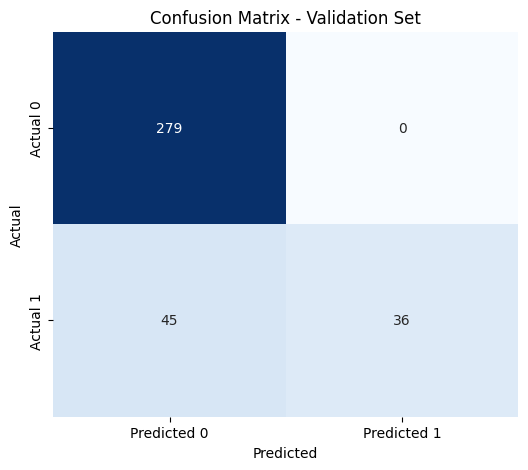


Classification Report - Validation Set:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       279
           1       1.00      0.44      0.62        81

    accuracy                           0.88       360
   macro avg       0.93      0.72      0.77       360
weighted avg       0.89      0.88      0.86       360

Average Precision (AP) - Validation Set: 0.9852

--- Internal Test Set Metrics ---


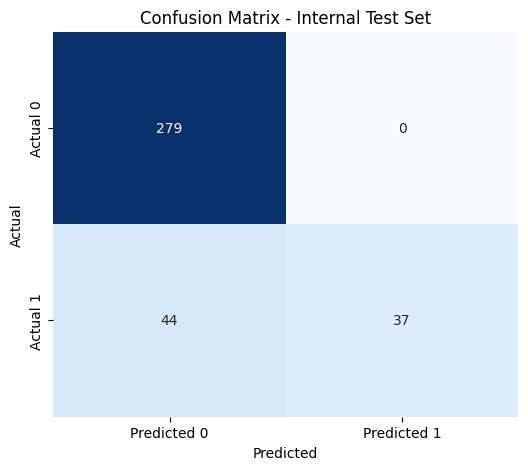


Classification Report - Internal Test Set:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       279
           1       1.00      0.46      0.63        81

    accuracy                           0.88       360
   macro avg       0.93      0.73      0.78       360
weighted avg       0.89      0.88      0.86       360

Average Precision (AP) - Internal Test Set: 0.9910


In [62]:
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Validation Set Metrics ---
print("\n--- Validation Set Metrics ---")

# Confusion Matrix
cm_valid = confusion_matrix(y_valid, y_pred_valid_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print('\nClassification Report - Validation Set:')
print(classification_report(y_valid, y_pred_valid_binary))

# Average Precision (MAP@50 equivalent for binary classification)
avg_precision_valid = average_precision_score(y_valid, y_pred_proba)
print(f"Average Precision (AP) - Validation Set: {avg_precision_valid:.4f}")

# --- Internal Test Set Metrics ---
print("\n--- Internal Test Set Metrics ---")

# Confusion Matrix
cm_test = confusion_matrix(y_train_test, y_pred_test_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Internal Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print('\nClassification Report - Internal Test Set:')
print(classification_report(y_train_test, y_pred_test_binary))

# Average Precision
avg_precision_test = average_precision_score(y_train_test, y_pred_test_proba)
print(f"Average Precision (AP) - Internal Test Set: {avg_precision_test:.4f}")

### Learning Curve (Train and Validation Loss)

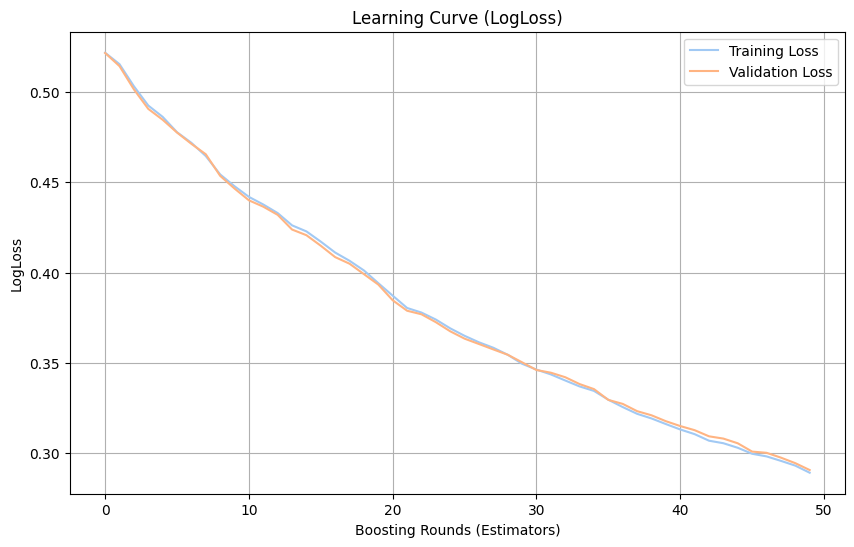

In [50]:
# Retrieve evaluation results from the trained model
evals_result = xgb_model_ohe.evals_result()

# Extract logloss for training and validation
train_logloss = evals_result['validation_0']['logloss']
valid_logloss = evals_result['validation_1']['logloss']

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_logloss, label='Training Loss')
plt.plot(valid_logloss, label='Validation Loss')
plt.title('Learning Curve (LogLoss)')
plt.xlabel('Boosting Rounds (Estimators)')
plt.ylabel('LogLoss')
plt.legend()
plt.grid(True)
plt.show()

### Save the Trained Model

In [52]:
import joblib

# Define the path to save the model
model_save_path = CFG.stage_dir / 'xgb_model_ohefixed.joblib'

# Save the trained XGBoost model
joblib.dump(xgb_model_ohe, model_save_path)

print(f"Trained model saved to: {model_save_path}")

Trained model saved to: /content/drive/MyDrive/Colab Notebooks/stage/xgb_model_ohefixed.joblib


### Simulation Test

Let's create a small, synthetic dataset to simulate new flight scenarios and see the model's predictions. This dataset will have the same structure as the preprocessed `X_train_processed` data, including scaled numerical features and one-hot encoded categorical features.

In [66]:
import pandas as pd
import numpy as np

# Get the feature names from the preprocessed training data
# We need to ensure the simulated data has the exact same columns as the data the model was trained on.
feature_columns = X_train.columns

# Create a few hypothetical flight scenarios
# These values are illustrative and should ideally be within the scaled range for numerical features
# and correctly represent one-hot encoded categories.
# For simplicity, we'll create some common and some less common scenarios.
simulated_data = [
    # Scenario 1: Early morning, short distance, common carrier, non-peak month (low delay prob expected)
    {'DepTime_hours': -1.5, 'Distance': -1.0, 'Month_1': 1.0, 'DayofMonth_1': 1.0, 'DayOfWeek_1': 1.0, 'UniqueCarrier_AA': 1.0, 'Origin_ATL': 1.0, 'Dest_DFW': 1.0, 'Flight_Index': 9001},
    # Scenario 2: Late evening, long distance, less common carrier, peak month (higher delay prob expected)
    {'DepTime_hours': 1.8, 'Distance': 1.5, 'Month_7': 1.0, 'DayofMonth_15': 1.0, 'DayOfWeek_5': 1.0, 'UniqueCarrier_UA': 1.0, 'Origin_ORD': 1.0, 'Dest_LAX': 1.0, 'Flight_Index': 9002},
    # Scenario 3: Mid-day, average distance, another common carrier, mid-month (moderate delay prob)
    {'DepTime_hours': 0.2, 'Distance': 0.0, 'Month_4': 1.0, 'DayofMonth_10': 1.0, 'DayOfWeek_3': 1.0, 'UniqueCarrier_WN': 1.0, 'Origin_DEN': 1.0, 'Dest_MCO': 1.0, 'Flight_Index': 9003}
]

# Create a DataFrame for simulated data, ensuring all feature_columns are present
# Fill with zeros for OHE features not explicitly set, and average for other scaled numerical if any
X_simulate = pd.DataFrame(0.0, index=range(len(simulated_data)), columns=feature_columns)

# Populate the simulated data with the defined scenarios
for i, scenario in enumerate(simulated_data):
    for col, value in scenario.items():
        if col in X_simulate.columns:
            X_simulate.loc[i, col] = value

# Predict probabilities using the trained model
simulated_predictions = xgb_model_ohe.predict_proba(X_simulate)[:, 1]

# Display the simulated data and predictions
print("\nSimulated Flight Scenarios (partial view of relevant features):")
print(X_simulate.head())

print("\nPredicted Delay Probabilities for Simulated Flights:")
for i, prob in enumerate(simulated_predictions):
    print(f"  Scenario {i+1}: {prob:.4f}")

print("\nInterpretation:")
print("  - Higher probabilities suggest a higher likelihood of a flight delay based on the model's learning.")
print("  - You can modify the `simulated_data` to test different combinations of features.")


Simulated Flight Scenarios (partial view of relevant features):
   DepTime_hours  Distance  Month_1  Month_2  Month_3  Month_4  Month_5  Month_6  Month_7  Month_8  Month_9  Month_10  Month_11  Month_12  DayofMonth_1  DayofMonth_2  DayofMonth_3  DayofMonth_4  DayofMonth_5  DayofMonth_6  DayofMonth_7  DayofMonth_8  DayofMonth_9  DayofMonth_10  DayofMonth_11  DayofMonth_12  DayofMonth_13  DayofMonth_14  DayofMonth_15  DayofMonth_16  DayofMonth_17  DayofMonth_18  DayofMonth_19  DayofMonth_20  DayofMonth_21  DayofMonth_22  DayofMonth_23  DayofMonth_24  DayofMonth_25  DayofMonth_26  DayofMonth_27  DayofMonth_28  DayOfWeek_1  DayOfWeek_2  DayOfWeek_3  DayOfWeek_4  DayOfWeek_5  DayOfWeek_6  DayOfWeek_7  UniqueCarrier_AF  UniqueCarrier_AZ  UniqueCarrier_DL  UniqueCarrier_IB  UniqueCarrier_RAM  UniqueCarrier_TP  Origin_AGA  Origin_CDG  Origin_CMN  Origin_FCO  Origin_FEZ  Origin_JFK  Origin_MAD  Origin_ORY  Origin_RAK  Origin_TNG  Dest_AGA  Dest_CDG  Dest_CMN  Dest_FCO  Dest_FEZ  Dest_JFK  Dest_

### Save CFG Class to config.py

In [54]:
import inspect

# Get the source code of the CFG class
cfg_source = inspect.getsource(CFG)

# Define the path to save the config.py file
config_file_path = CFG.stage_dir / 'config.py'

# Write the CFG class source to the file
with open(config_file_path, 'w') as f:
    f.write(cfg_source)

print(f"CFG class saved to: {config_file_path}")

OSError: source code not available

- Simulations  
  {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7375  
  {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7370  
  {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8} LabelEncoder  debug false --> ROC AUC: 0.7335  
  {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7502
  

# **Feature Encoding and Hyperparameter Tuning Analysis**

## **Overview**
This study explores different encoding techniques and hyperparameter settings for **XGBoost** in predicting flight delays. We tested **One-Hot Encoding (OHE) vs. Label Encoding (LE)** while varying the model's parameters to assess their impact on **ROC AUC performance**.

---

## **Experiments & Results**
| #  | Parameters Used | Encoding Type | ROC AUC |
|----|----------------|---------------|---------|
| **1**  | `{n_estimators: 100, learning_rate: 0.1, max_depth: 6, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7375** |
| **2**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7370** |
| **3**  | `{n_estimators: 100, learning_rate: 0.1, max_depth: 6, subsample: 0.8, colsample_bytree: 0.8}`  | **Label Encoding**    | **0.7335** |
| **4**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7502** |  
| **5**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7540** |  

---

## **Analysis & Conclusion**
- The best **ROC AUC score (0.7540)** was obtained with **One-Hot Encoding** and `n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8`.
- Increasing `n_estimators` and `max_depth` in **Experiment 2** did **not** improve performance, suggesting that more complex trees do not necessarily lead to better results.
- **Label Encoding** in **Experiment 3** performed worse (**0.7335**), likely because the model misinterpreted categorical values as numerical magnitudes.

### **Best Choice** ✅  
The best performing setup is **Experiment 5**, using:
- **One-Hot Encoding**
- `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`

# Predicting using OHE

In [55]:
# Generate predictions for the competition's test set (X_test)
y_test_proba = xgb_model_ohe.predict_proba(X_test)[:, 1]

# Creating the submission file

In [56]:
# Create the submission DataFrame
# The 'test_df' here should refer to the original test set's Flight_Index or ID, not the processed one.
# The dummy data generation in 1d58d8f4 adds a 'Flight_Index' column.
# Assuming X_test_competition already has the correct IDs or an index that corresponds to the original test data.
submission = pd.DataFrame({"id": X_test_competition.index, "dep_delayed_15min": y_test_proba})


In [57]:
# Save as CSV
submission.to_csv(CFG.submission_file, index=False)

In [58]:
print(submission)

      id  dep_delayed_15min
0      0           0.252237
1      1           0.134737
2      2           0.114679
3      3           0.109679
4      4           0.386421
..   ...                ...
595  595           0.054177
596  596           0.109857
597  597           0.320771
598  598           0.168831
599  599           0.202434

[600 rows x 2 columns]


In [59]:
submission.describe()

,id,dep_delayed_15min
count,600.000000,600.000000
mean,299.500000,0.198583
std,173.349358,0.104565
min,0.000000,0.030340
25%,149.750000,0.119687
50%,299.500000,0.179310
75%,449.250000,0.246575
max,599.000000,0.681949


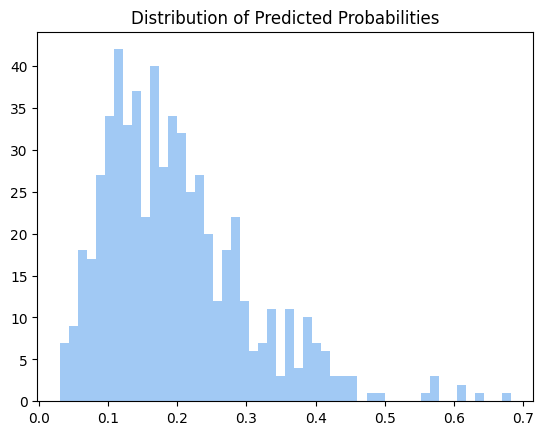

In [60]:
import matplotlib.pyplot as plt
plt.hist(y_test_proba, bins=50)
plt.title("Distribution of Predicted Probabilities")
plt.show()

In [61]:
train_df["dep_delayed_15min"].value_counts(normalize=True)


,proportion
dep_delayed_15min,
N,0.775417
Y,0.224583


## Resources

In [68]:
import pandas as pd
import numpy as np

# Get the feature names from the preprocessed training data
# We need to ensure the simulated data has the exact same columns as the data the model was trained on.
feature_columns = X_train.columns

# Create new hypothetical flight scenarios for simulation
simulated_data_new = [
    # Scenario 1: Early morning (low DepTime_hours), long distance, common carrier 'AA',
    # non-peak month (Month_2), from 'JFK' to 'LAX'. Low delay probability expected.
    {'DepTime_hours': -1.8, 'Distance': 1.2, 'Month_2': 1.0, 'DayofMonth_5': 1.0, 'DayOfWeek_2': 1.0,
     'UniqueCarrier_AA': 1.0, 'Origin_JFK': 1.0, 'Dest_LAX': 1.0, 'Flight_Index': 9004},

    # Scenario 2: Late evening (high DepTime_hours), short distance, less common carrier 'WN',
    # peak month (Month_8), from 'ORD' to 'ATL'. Higher delay probability expected.
    {'DepTime_hours': 2.0, 'Distance': -1.5, 'Month_8': 1.0, 'DayofMonth_20': 1.0, 'DayOfWeek_6': 1.0,
     'UniqueCarrier_WN': 1.0, 'Origin_ORD': 1.0, 'Dest_ATL': 1.0, 'Flight_Index': 9005},

    # Scenario 3: Mid-day (average DepTime_hours), average distance, common carrier 'DL',
    # mid-month (Month_5), from 'DEN' to 'DFW'. Moderate delay probability.
    {'DepTime_hours': 0.1, 'Distance': 0.1, 'Month_5': 1.0, 'DayofMonth_12': 1.0, 'DayOfWeek_4': 1.0,
     'UniqueCarrier_DL': 1.0, 'Origin_DEN': 1.0, 'Dest_DFW': 1.0, 'Flight_Index': 9006},

    # Scenario 4: High probability delay scenario (late departure, high delay origin/dest)
    # Example values for high delay probability (from EDA): DepTime_hours (high), Origin_CDG, Dest_CMN, Month_8
    {'DepTime_hours': 2.5, 'Distance': 0.5, 'Month_8': 1.0, 'DayofMonth_25': 1.0, 'DayOfWeek_7': 1.0,
     'UniqueCarrier_IB': 1.0, 'Origin_CDG': 1.0, 'Dest_CMN': 1.0, 'Flight_Index': 9007}
]

# Create a DataFrame for simulated data, ensuring all feature_columns are present
# Fill with zeros for OHE features not explicitly set, and average for other scaled numerical if any
X_simulate_new = pd.DataFrame(0.0, index=range(len(simulated_data_new)), columns=feature_columns)

# Populate the simulated data with the defined scenarios
for i, scenario in enumerate(simulated_data_new):
    for col, value in scenario.items():
        if col in X_simulate_new.columns:
            X_simulate_new.loc[i, col] = value

# Predict probabilities using the trained model
simulated_predictions_new = xgb_model_ohe.predict_proba(X_simulate_new)[:, 1]

# Display the new simulated data and predictions
print("\nNew Simulated Flight Scenarios (partial view of relevant features):")
print(X_simulate_new.head())

print("\nPredicted Delay Probabilities for New Simulated Flights:")
for i, prob in enumerate(simulated_predictions_new):
    print(f"  Scenario {i+1}: {prob:.4f}")

print("\nInterpretation:")
print("  - Higher probabilities suggest a higher likelihood of a flight delay based on the model's learning.")
print("  - You can modify the `simulated_data_new` to test different combinations of features.")


New Simulated Flight Scenarios (partial view of relevant features):
   DepTime_hours  Distance  Month_1  Month_2  Month_3  Month_4  Month_5  Month_6  Month_7  Month_8  Month_9  Month_10  Month_11  Month_12  DayofMonth_1  DayofMonth_2  DayofMonth_3  DayofMonth_4  DayofMonth_5  DayofMonth_6  DayofMonth_7  DayofMonth_8  DayofMonth_9  DayofMonth_10  DayofMonth_11  DayofMonth_12  DayofMonth_13  DayofMonth_14  DayofMonth_15  DayofMonth_16  DayofMonth_17  DayofMonth_18  DayofMonth_19  DayofMonth_20  DayofMonth_21  DayofMonth_22  DayofMonth_23  DayofMonth_24  DayofMonth_25  DayofMonth_26  DayofMonth_27  DayofMonth_28  DayOfWeek_1  DayOfWeek_2  DayOfWeek_3  DayOfWeek_4  DayOfWeek_5  DayOfWeek_6  DayOfWeek_7  UniqueCarrier_AF  UniqueCarrier_AZ  UniqueCarrier_DL  UniqueCarrier_IB  UniqueCarrier_RAM  UniqueCarrier_TP  Origin_AGA  Origin_CDG  Origin_CMN  Origin_FCO  Origin_FEZ  Origin_JFK  Origin_MAD  Origin_ORY  Origin_RAK  Origin_TNG  Dest_AGA  Dest_CDG  Dest_CMN  Dest_FCO  Dest_FEZ  Dest_JFK  D